# Learning the PDE Solution: FNO vs MLP vs PINN

This notebook unifies the forward-learning experiments from the original FNO and PINN practicals.
It compares three models on the backwater problem:

- FNO trained from observations
- MLP trained from observations only
- PINN trained from observations and PDE residuals

The notebook also includes the full study on the impact of `N_obs`.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import torch

import display
from Backwater_model import compute_ref_solution
from normalization import normalize_input
from study_utils import (
    build_fno,
    build_mlp,
    build_observations,
    build_pinn,
    default_device,
    default_problem,
    plot_n_obs_study,
    run_n_obs_study,
    save_n_obs_results,
)
from trainer import PITrainer, Trainer

print('Pytorch version:', torch.__version__)


Pytorch version: 2.11.0


## Setup

Choose the device and define the reference backwater configuration.

Running on cpu!


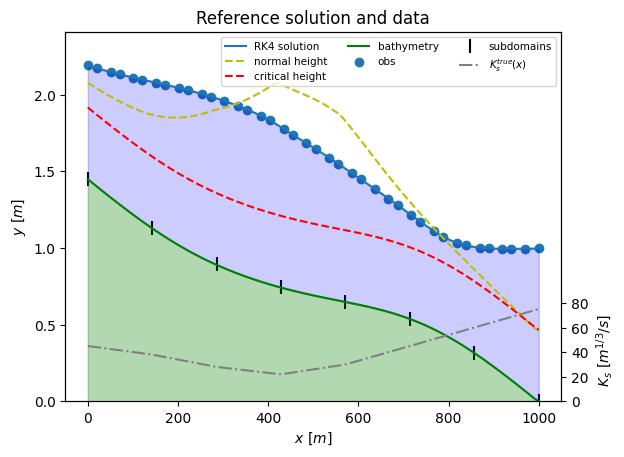

In [2]:
device = default_device(use_gpu=True)
print(f'Running on {device}!')
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

k_true, col = default_problem(device, seed=0)
reference_model = build_pinn(device, k_true, seed=0)
ref_solution = compute_ref_solution(reference_model, col, k=k_true, dx=10)

obs = build_observations(ref_solution, n_obs=40, seed=None)
display.display_data(reference_model, col, ref_solution, obs)


## FNO Baseline

This reproduces the original PP2 experiment where the FNO learns the solution from the observation set.

##################################################
Processing iteration 50
-------------------------
J_obs       = 2.76e-04
||grad(J)|| = 5.54e-02
time        = 0.99 s
##################################################
Processing iteration 100
-------------------------
J_obs       = 3.30e-06
||grad(J)|| = 6.13e-03
time        = 1.18 s
##################################################
Processing iteration 150
-------------------------
J_obs       = 5.01e-09
||grad(J)|| = 9.71e-05
time        = 1.30 s
##################################################
Processing iteration 200
-------------------------
J_obs       = 6.54e-09
||grad(J)|| = 2.76e-04
time        = 1.43 s
##################################################
Processing iteration 250
-------------------------
J_obs       = 5.83e-09
||grad(J)|| = 2.62e-04
time        = 1.54 s
##################################################
Processing iteration 300
-------------------------
J_obs       = 4.86e-09
||grad(J)|| = 2.39e-04
time    

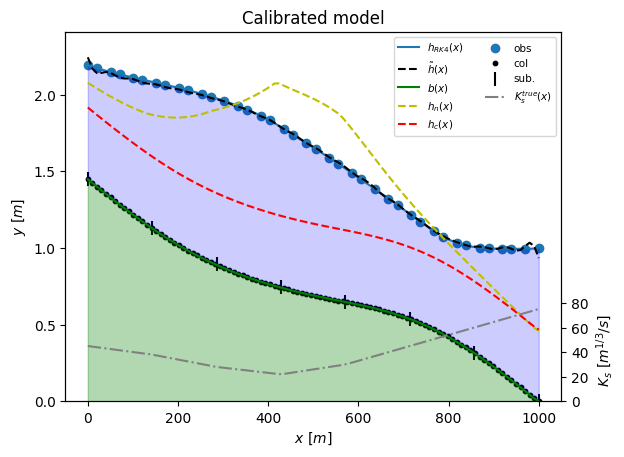

In [3]:
fno_model = build_fno(device, seed=0)
fno_trainer = Trainer()
fno_result = fno_trainer.fit(
    fno_model,
    col,
    obs,
    ref_solution,
    n_iter=300,
    lr=1e-2,
    display_freq=(50, 100),
)
fno_rmse = display.display_training(fno_model, col, ref_solution)
display.display_results(fno_model, col, ref_solution, obs, plot_col=True)


## MLP Without Physics Loss

A dedicated observation-driven `MLP` class is used for the non-physics baseline.

##################################################
Processing iteration 50
-------------------------
J_obs       = 7.66e-03
||grad(J)|| = 5.43e-02
time        = 0.05 s
##################################################
Processing iteration 100
-------------------------
J_obs       = 2.89e-03
||grad(J)|| = 3.30e-02
time        = 0.14 s
##################################################
Processing iteration 150
-------------------------
J_obs       = 2.06e-04
||grad(J)|| = 3.26e-02
time        = 0.25 s
##################################################
Processing iteration 200
-------------------------
J_obs       = 4.38e-05
||grad(J)|| = 7.09e-03
time        = 0.34 s
##################################################
Processing iteration 250
-------------------------
J_obs       = 2.51e-05
||grad(J)|| = 2.62e-03
time        = 0.43 s
##################################################
Processing iteration 300
-------------------------
J_obs       = 1.07e-05
||grad(J)|| = 6.99e-03
time    

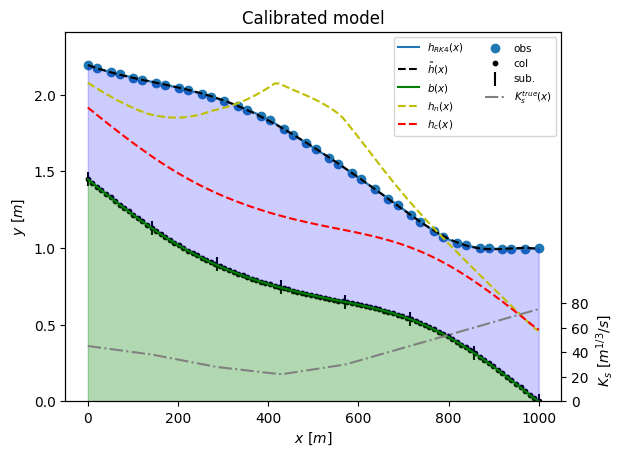

In [4]:
mlp_model = build_mlp(device, seed=0)
mlp_trainer = Trainer(optimizer_name="lbfgs")
mlp_result = mlp_trainer.fit(
    mlp_model,
    col,
    obs,
    ref_solution,
    n_iter=300,
    lr=1e-2,
    display_freq=(50, 100),
)
mlp_rmse = display.display_training(mlp_model, col, ref_solution)
display.display_results(mlp_model, col, ref_solution, obs, plot_col=True)


## PINN With Physics Loss

The residual and boundary-condition terms are now activated during training.

##################################################
Processing evaluation 50
-------------------------
J           = 2.52e-02 (residual : 2.17e-04, obs : 2.35e-02, BC : 1.64e-03)
||grad(J)|| = 2.08e-02
parameter    = tensor([45., 38., 28., 22., 30., 45., 60., 75.])
time         = 0.13 s
##################################################
Processing evaluation 100
-------------------------
J           = 2.82e-04 (residual : 1.47e-05, obs : 2.73e-04, BC : 8.85e-06)
||grad(J)|| = 6.89e-02
parameter    = tensor([45., 38., 28., 22., 30., 45., 60., 75.])
time         = 0.29 s
##################################################
Processing evaluation 150
-------------------------
J           = 7.69e-05 (residual : 3.93e-06, obs : 7.26e-05, BC : 3.74e-07)
||grad(J)|| = 6.59e-05
parameter    = tensor([45., 38., 28., 22., 30., 45., 60., 75.])
time         = 0.43 s
##################################################
Processing evaluation 200
-------------------------
J           = 7.69e-05 (residual :

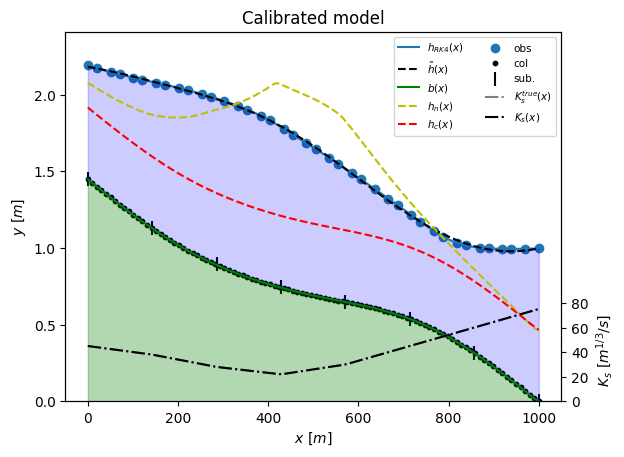

In [5]:
pinn_model = build_pinn(device, k_true, seed=0)
pinn_trainer = PITrainer(train_k=False)
pinn_result = pinn_trainer.fit(
    pinn_model,
    col,
    obs,
    ref_solution,
    pre_train_iter=100,
    alter_steps=4,
    alter_freq=(40, 0),
    normalize_losses=True,
    display_freq=(50, 100),
)
pinn_rmse = display.display_training(pinn_model, col, ref_solution)
display.display_results(pinn_model, col, ref_solution, obs, plot_col=True)


## Direct Comparison

Compare the three predictions on the same test case.

In [6]:
rmse_table = {
    'FNO': fno_rmse,
    'MLP without PINN': mlp_rmse,
    'MLP with PINN': pinn_rmse,
}
rmse_table

{'FNO': np.float32(0.014526715),
 'MLP without PINN': np.float32(0.0031254687),
 'MLP with PINN': np.float32(0.009351085)}

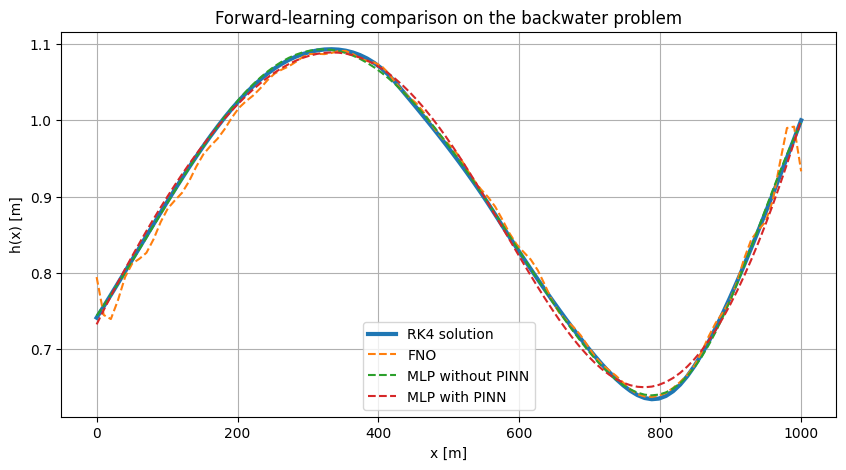

In [7]:
x = col.detach().clone().cpu().numpy().flatten()
h_true = ref_solution['solution'].detach().clone().cpu().numpy().flatten()
h_fno = fno_model(normalize_input(col, col)).detach().clone().cpu().numpy().flatten()
h_mlp = mlp_model(normalize_input(col, col)).detach().clone().cpu().numpy().flatten()
h_pinn = pinn_model(normalize_input(col, col)).detach().clone().cpu().numpy().flatten()

plt.figure(figsize=(10, 5))
plt.plot(x, h_true, label='RK4 solution', linewidth=3)
plt.plot(x, h_fno, '--', label='FNO')
plt.plot(x, h_mlp, '--', label='MLP without PINN')
plt.plot(x, h_pinn, '--', label='MLP with PINN')
plt.xlabel('x [m]')
plt.ylabel('h(x) [m]')
plt.title('Forward-learning comparison on the backwater problem')
plt.grid(True)
plt.legend()
plt.show()


## Study on `N_obs`

This reproduces the full study requested in `Instructions.md` for:

- FNO
- MLP without PINN loss
- MLP with PINN loss

##################################################
Processing iteration 500
-------------------------
J_obs       = 5.42e-05
||grad(J)|| = 4.50e-05
time        = 0.65 s
##################################################
Processing iteration 500
-------------------------
J_obs       = 6.90e-05
||grad(J)|| = 1.81e-04
time        = 0.80 s
##################################################
Processing iteration 1000
-------------------------
J_obs       = 6.90e-05
||grad(J)|| = 6.96e-05
time        = 1.43 s
##################################################
Processing evaluation 500
-------------------------
J           = 6.76e-05 (residual : 3.85e-06, obs : 6.37e-05, BC : 7.82e-08)
||grad(J)|| = 6.77e-05
parameter    = tensor([45., 38., 28., 22., 30., 45., 60., 75.])
time         = 0.91 s
##################################################
Processing evaluation 1000
-------------------------
J           = 6.76e-05 (residual : 3.85e-06, obs : 6.37e-05, BC : 7.82e-08)
||grad(J)|| = 6.77e-05
p

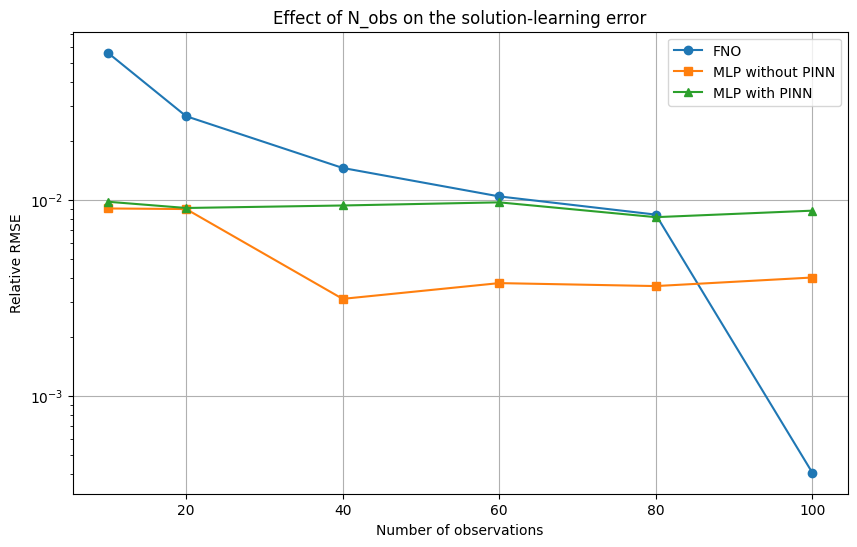

In [8]:
fno_results = run_n_obs_study('fno', use_pinn=False)
mlp_results = run_n_obs_study('pinn', use_pinn=False)
pinn_results = run_n_obs_study('pinn', use_pinn=True)

save_n_obs_results('n_obs_study_fno.npz', fno_results)
save_n_obs_results('n_obs_study_mlp.npz', mlp_results)
save_n_obs_results('n_obs_study_pinn.npz', pinn_results)

fig, ax = plot_n_obs_study(fno_results, mlp_results, pinn_results)
fig.savefig('n_obs_study_comparison.png', bbox_inches='tight')
plt.show()

### Interpretation Prompt

Use the graph above to discuss:

- how the error decreases when more observations are available,
- whether the PINN loss improves sample efficiency,
- why the FNO may create oscillations between observations in this setting.